# Fashion Forward Forecasting

## Project Overview

The objective of this project is to build a machine learning pipeline that predicts whether a customer would recommend a clothing product or not based on the following features available to us:

- Customer information
- Product information
- Review title
- Review text

The project includes:
1. Data Exploration
2. Data Preprocessing
3. NLP Feature Engineering
4. Pipeline Construction
5. Model Training
6. Hyperparameter Tuning
7. Model Evaluation
8. Conclusions

# 0. Import Initial Libraries and Load Data

In [1]:
# Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load data
def load_data(file_path):
    df=pd.read_csv(file_path)
    return df
    
df=load_data(r"C:\Users\QE50MA\Downloads\reviews.csv")

# 1. Prepare Features and Target

In [2]:
# Separate features and target
X = df.drop("Recommended IND", axis=1)
y = df["Recommended IND"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=True, random_state=27)

# 2. Data Exploration

In [3]:
# get dataframe information
def df_info (df):
    return df.info()
    
df_info (df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


In [4]:
# observe the first five rows of the dataframe
def df_head (df):
    return df.head()
    
df_head (df)

,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## 2.1 Class distribution

In [5]:
# check the class distribution of the target column and also its normalized value
def value_counts (column):
    print('value counts:', column.value_counts())
    print()
    print('Normalized:', column.value_counts(normalize=True))

value_counts (y)

value counts: Recommended IND
1    15053
0     3389
Name: count, dtype: int64

Normalized: Recommended IND
1    0.816235
0    0.183765
Name: proportion, dtype: float64


In [6]:
def df_describe (df):
    return df.describe()

df_describe (df)

,Clothing ID,Age,Positive Feedback Count,Recommended IND
count,18442.000000,18442.000000,18442.000000,18442.000000
mean,954.896757,43.383635,2.697484,0.816235
std,141.571783,12.246264,5.942220,0.387303
min,2.000000,18.000000,0.000000,0.000000
25%,863.000000,34.000000,0.000000,1.000000
50%,952.000000,41.000000,1.000000,1.000000
75%,1078.000000,52.000000,3.000000,1.000000
max,1205.000000,99.000000,122.000000,1.000000


In [7]:
# look deeper at categorical columns
def categorical_columns (df):
    cols=df.select_dtypes(object).columns.tolist()
    for col in cols:
        print(f"\n{col}")
        print("-" * 25)
        print("Unique values:", df[col].nunique())
        print(df[col].value_counts().head())

categorical_columns (df)


Title
-------------------------
Unique values: 13142
Title
Love it!      129
Beautiful      88
Love           81
Love!          79
Beautiful!     71
Name: count, dtype: int64

Review Text
-------------------------
Unique values: 18439
Review Text
I bought this shirt at the store and after going home and trying it on, i promptly went online and ordered two more! i've gotten multiple compliments anytime i wear any of them. great for looking put together with no fuss. \r\npeople that have commented there's were destroyed in the wash didn't read the care label which says dry clean.                                                                                                                                                                         2
I purchased this and another eva franco dress during retailer's recent 20% off sale. i was looking for dresses that were work appropriate, but that would also transition well to happy hour or date night. they both seemed to be just what i was l

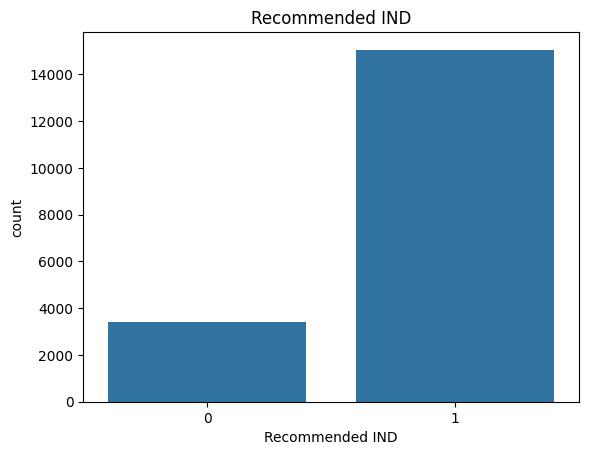

In [8]:
# define a function that displays the target column distribution
def targetcol_distribution (df, targetcolumn):
    sns.countplot(x=targetcolumn, data=df)
    plt.title(targetcolumn)
    plt.show()

targetcol_distribution (df, "Recommended IND")

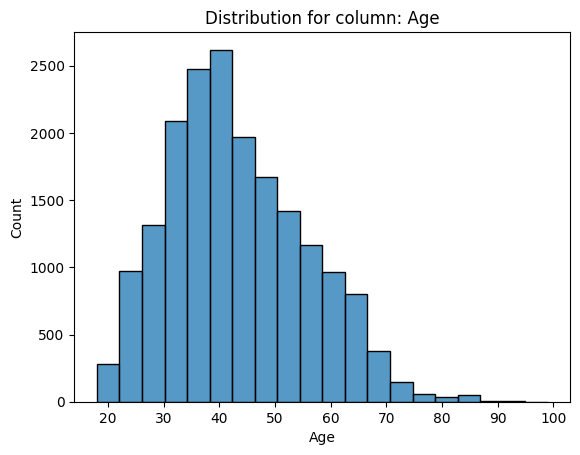

In [9]:
# define a function that displays columns' distributions
def column_distribution (df, column):
    sns.histplot(df[column], bins=20)
    plt.title(f"Distribution for column: {column}")
    plt.show()

column_distribution (df, 'Age')

The dataset contains 18,442 reviews and no missing values. The target variable is moderately imbalanced, with approximately 82% of reviews recommending the product. The dataset includes numerical, categorical, and text features, making it appropriate for a preprocessing pipeline using multiple transformers. Text fields are expected to provide substantial predictive power, while categorical variables can be encoded using one-hot encoding.

# 4. Build Pipeline

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
# Define feature groups
numerical_features = [
    "Age",
    "Positive Feedback Count"]

categorical_features = [
    "Clothing ID",
    "Division Name",
    "Department Name",
    "Class Name"]

text_feature = "Review Text"

In [12]:
# Numerical preprocessing pipeline
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())])

numerical_pipeline

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [13]:
# Categorical preprocessing pipeline
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))])

categorical_pipeline

,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [14]:
# Text preprocessing pipeline
text_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer())])

text_pipeline

,steps,"[('tfidf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [15]:
# Combine preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features),
        ("text", TfidfVectorizer(), text_feature)])

preprocessor

,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [16]:
from sklearn.linear_model import LogisticRegression
# Full machine learning pipeline
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))])

model_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# 5. Train Pipeline

In [17]:
# Train pipeline
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 5.1. Baseline Model Evaluation

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
y_pred = model_pipeline.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8785907859078591
Precision: 0.9028642590286425
Recall: 0.9552042160737813
F1: 0.9282970550576184
              precision    recall  f1-score   support

           0       0.72      0.52      0.60       327
           1       0.90      0.96      0.93      1518

    accuracy                           0.88      1845
   macro avg       0.81      0.74      0.77      1845
weighted avg       0.87      0.88      0.87      1845



### Baseline Model Evaluation

The baseline Logistic Regression pipeline achieved strong overall performance with an accuracy of 87.9% and an F1-score of 92.8%.

However, the classification report reveals that the model performs significantly better for recommended products (class 1) than for non-recommended products (class 0). This is likely due to the class imbalance in the dataset, where approximately 82% of reviews are positive recommendations.

To improve performance, hyperparameter tuning will be performed using GridSearchCV to identify the best model configuration.

# 6. Fine-Tune Pipeline

In [20]:
from sklearn.model_selection import GridSearchCV
param_grid = {"classifier__C": [0.1, 1, 10], "classifier__class_weight": [None, "balanced"]}
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'classifier__C': [0.1, 1, ...], 'classifier__class_weight': [None, 'balanced']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


In [21]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__C': 10, 'classifier__class_weight': None}


## 6.1 Fine-Tuned Model Evaluation

In [22]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
print(classification_report(y_test, y_pred_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1:", f1_score(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.68      0.61      0.64       327
           1       0.92      0.94      0.93      1518

    accuracy                           0.88      1845
   macro avg       0.80      0.77      0.79      1845
weighted avg       0.88      0.88      0.88      1845

Accuracy: 0.8802168021680217
Precision: 0.9181173436492586
Recall: 0.9380764163372859
F1: 0.9279895731508635


In [23]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred_tuned)
print(cm)

[[ 200  127]
 [  94 1424]]


### Fine-Tuning Results

GridSearchCV was used to optimize the Logistic Regression classifier.

Best Parameters:

- C = 10
- class_weight = None

The tuned model improved the prediction performance for the minority class (non-recommended reviews). The recall for class 0 improved from 0.52 to 0.61 and the F1-score improved from 0.60 to 0.64.

Although overall accuracy remained similar, the tuned model provides a more balanced classification performance and was selected as the final model.

### Evaluation Summary

The final model was evaluated on the held-out test dataset using accuracy, precision, recall, F1-score, and a confusion matrix.

The tuned Logistic Regression model achieved an overall accuracy of approximately 88%.

Performance was strongest for recommended products (class 1), achieving a precision of 0.92, recall of 0.94, and F1-score of 0.93.

For non-recommended products (class 0), the model achieved a precision of 0.68, recall of 0.61, and F1-score of 0.64. While performance on the minority class remains lower than the majority class, hyperparameter tuning improved the ability to identify non-recommended products compared to the baseline model.

The confusion matrix showed that 200 non-recommended reviews and 1,424 recommended reviews were correctly classified.

# 7. Conclusions

The objective of this project was to develop a machine learning pipeline capable of predicting whether a customer would recommend a clothing product based on numerical, categorical, and text-based review information.

The dataset contained 18,442 customer reviews and included several feature types, including customer age, product information, review text, and review titles. Initial exploration showed no missing values within the dataset, allowing the focus to remain on feature preparation and model development. The target variable was moderately imbalanced, with approximately 82% of reviews recommending a product and 18% not recommending a product.

A machine learning pipeline was developed using separate preprocessing strategies for numerical, categorical, and text features. Numerical features were scaled using StandardScaler, categorical features were encoded using OneHotEncoder, and review text was transformed into numerical features using TF-IDF vectorization. These preprocessing steps were combined using a ColumnTransformer and integrated directly into a Logistic Regression pipeline.

Hyperparameter tuning was performed using GridSearchCV with cross-validation. The best-performing model used a Logistic Regression classifier with C=10 and no class weighting. The tuned model achieved approximately 88% accuracy on the test dataset while improving the identification of non-recommended products compared to the baseline model.

Although additional NLP techniques such as stemming, lemmatization, and custom normalization were considered, they were not implemented in the final pipeline. TF-IDF vectorization already performs tokenization and text feature extraction and produced strong predictive performance without additional linguistic preprocessing. Given the high model performance and the relatively clean review text data, further NLP transformations were not expected to provide significant improvements while increasing model complexity and training time.

Overall, the final pipeline successfully handled numerical, categorical, and text data within a single end-to-end workflow and demonstrated strong performance in predicting customer recommendations.